# Bayesian Modelling - EDA

## Load Data

In [1]:
# Constants
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get repo root
REPO_ROOT = Path(os.getcwd()).resolve().parent
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
print(REPO_ROOT)


/Users/srihariraman/Desktop/Projects/311-Service_Request-Modelling


In [2]:
# Load Bayesian data. If not already there, run scripts/utility/preprocessing.py
df = pd.read_parquet(PROCESSED_DIR / "bayesian_preprocessed.parquet")
df.head()

,date,neighborhood,count
0,2019-01-01,Allston / Brighton,21
1,2019-01-02,Allston / Brighton,55
2,2019-01-03,Allston / Brighton,62
3,2019-01-04,Allston / Brighton,55
4,2019-01-05,Allston / Brighton,36


In [3]:
df.shape

(37252, 3)

## Exploring the Distribution

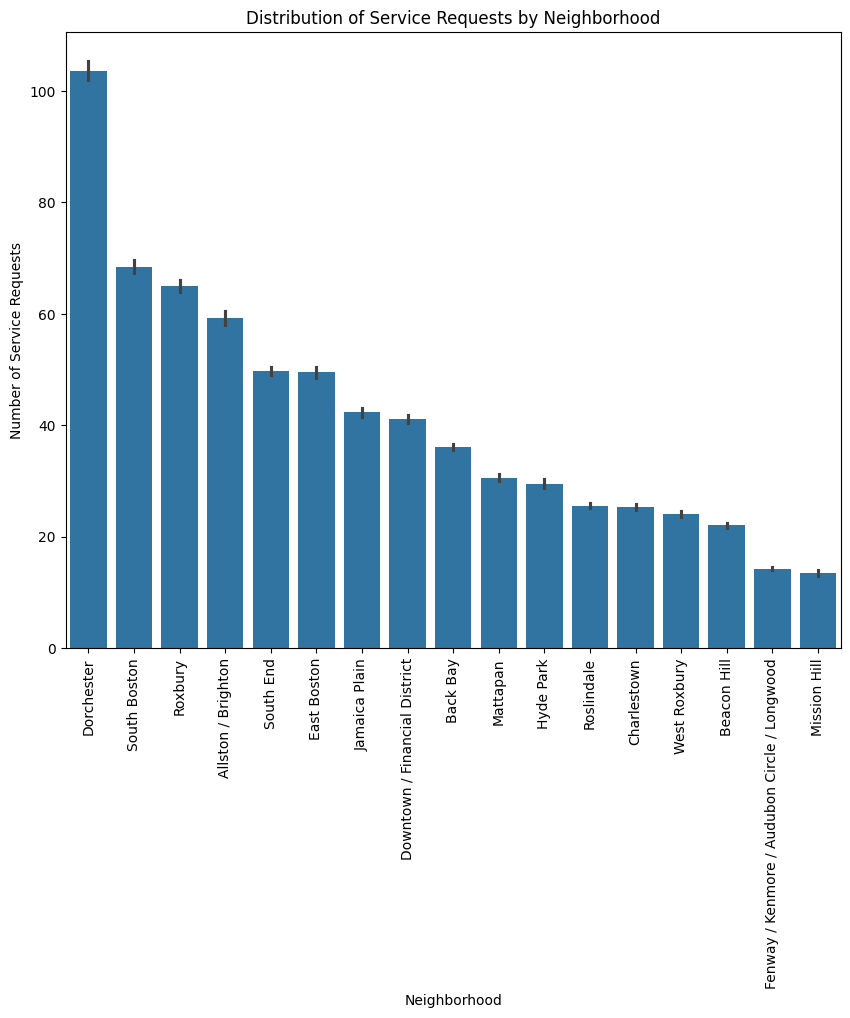

In [4]:
# Graph the distribution of service requests by neighborhood
plt.figure(figsize=(10, 8))
sns.barplot(x="neighborhood", y="count", data=df, order=df.groupby("neighborhood")["count"].mean().sort_values(ascending=False).index)
plt.xticks(rotation=90)
plt.xlabel("Neighborhood")
plt.ylabel("Number of Service Requests")
plt.title("Distribution of Service Requests by Neighborhood");

**In general, we know the following about service requests:**

- 311 Requests cannot have a negative count in any neighborhood
- The request count in all neighborhoods must be a discrete value (cannot have a fraction of a request)
- Domain is in demand forecasting
- Potential likelihood distribution --> Poisson or Negative Binomial distributions

In [5]:
# Checking ratio of variance to mean --> if close to 1, Poisson is fine, otherwise use Negative Binomial
stats = (
    df.groupby("neighborhood")["count"]
    .agg(mean="mean", var="var")
    .assign(dispersion=lambda x: x["var"] / x["mean"])
    .sort_values("dispersion", ascending=False)
    .round(2)
)
print(stats)


print(f"\nOverall dispersion: {df['count'].var() / df['count'].mean():.2f}")

                                                mean      var  dispersion
neighborhood                                                             
Dorchester                                    103.67  1606.49       15.50
Allston / Brighton                             59.31   861.91       14.53
South Boston                                   68.39   896.15       13.10
East Boston                                    49.53   589.15       11.90
Roxbury                                        64.94   709.35       10.92
Mission Hill                                   13.42   131.11        9.77
Hyde Park                                      29.52   288.06        9.76
Mattapan                                       30.58   264.32        8.64
Downtown / Financial District                  41.07   312.59        7.61
Jamaica Plain                                  42.28   314.35        7.43
Charlestown                                    25.24   172.21        6.82
Beacon Hill                           

Clearly, the negative binomial distribution is the right likelihood to use for this.

In [6]:
# Break down the date into month, year, and day of week
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df["day_of_week"] = df["date"].dt.dayofweek

# Remove date column
df = df.drop(columns=["date"])

# Set neighborhood, month, year, and day of week as categorical variables
df["neighborhood"] = df["neighborhood"].astype("category")
df["month"] = df["month"].astype("category")
df["day_of_week"] = df["day_of_week"].astype("category")

df.head()

,neighborhood,count,month,year,day_of_week
0,Allston / Brighton,21,1,2019,1
1,Allston / Brighton,55,1,2019,2
2,Allston / Brighton,62,1,2019,3
3,Allston / Brighton,55,1,2019,4
4,Allston / Brighton,36,1,2019,5


In [7]:
df.dtypes


neighborhood    category
count              int64
month           category
year               int32
day_of_week     category
dtype: object

In [10]:
if not os.path.exists(PROCESSED_DIR / "bayesian_preprocessed_final.parquet"):
    df.to_parquet(PROCESSED_DIR / "bayesian_preprocessed_final.parquet", index=False)
    print("Exported Bayesian model inputs to parquet.")
else:
    print("Bayesian model inputs already exist in parquet.")


Bayesian model inputs already exist in parquet.


**For prior distributions:**
- 